# Component Noise Experiment

Core question:
- How sensitive are DeiT blocks to activation noise in the `residual` stream, `attention` output, and `FFN` output?
- Does the sensitivity differ for single-layer perturbations versus cumulative perturbations from layer `0..l`?

In [9]:
from contextlib import contextmanager
from dataclasses import asdict, dataclass
from pathlib import Path
from types import MethodType
from typing import Dict, List, Optional, Sequence
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, DeiTForImageClassificationWithTeacher, ViTForImageClassification

sns.set_theme(style="whitegrid")


COMPONENTS = ("residual", "attention", "ffn")
NOISE_MODES = ("per_layer", "cumulative")
COMPONENT_COLORS = {
    "residual": "#1f77b4",
    "attention": "#d62728",
    "ffn": "#2ca02c",
}


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = choose_device()
print(f"Using device: {device}")


@dataclass(frozen=True)
class ModelSpec:
    name: str
    repo_id: str
    imagenet_top1: float
    imagenet_top5: float
    params: str
    is_distilled: bool = False


MODEL_SPECS: List[ModelSpec] = [
    ModelSpec("DeiT-tiny", "facebook/deit-tiny-patch16-224", 72.2, 91.1, "5M"),
    ModelSpec("DeiT-small", "facebook/deit-small-patch16-224", 79.9, 95.0, "22M"),
    ModelSpec("DeiT-base", "facebook/deit-base-patch16-224", 81.8, 95.6, "86M"),
    ModelSpec("DeiT-tiny distilled", "facebook/deit-tiny-distilled-patch16-224", 74.5, 91.9, "6M", True),
    ModelSpec("DeiT-small distilled", "facebook/deit-small-distilled-patch16-224", 81.2, 95.4, "22M", True),
    ModelSpec("DeiT-base distilled", "facebook/deit-base-distilled-patch16-224", 83.4, 96.5, "87M", True),
    ModelSpec("DeiT-base 384", "facebook/deit-base-patch16-384", 82.9, 96.2, "87M"),
    ModelSpec("DeiT-base distilled 384", "facebook/deit-base-distilled-patch16-384", 85.2, 97.2, "88M", True),
]


EXPERIMENT_CONFIG = {
    "dataset_name": "pouya-haghi/imagenet-1k",
    "split": "train",
    # Fastest all-models path: keep all models and all layers, but avoid cumulative mode for now.
    "selected_model_names": [spec.name for spec in MODEL_SPECS],
    "accuracy_batch_size": 16,
    "accuracy_batch_size_384": 4,
    "noise_eval_samples": 128,
    "alphas": [0.0, 0.25, 0.5, 0.75, 1.0],
    "component_noise_modes": ["per_layer"],
    "component_noise_components": list(COMPONENTS),
    "component_noise_target_layers": None,
    "results_dir": "component_noise_results",
    "show_progress": True,
}

pd.DataFrame([asdict(spec) for spec in MODEL_SPECS])

Using device: cuda


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [10]:
def slugify(value: str) -> str:
    return value.lower().replace("-", "_").replace(" ", "_")


def select_model_specs(selected_names: Optional[Sequence[str]] = None) -> List[ModelSpec]:
    if not selected_names:
        return MODEL_SPECS

    selected_name_set = set(selected_names)
    selected = [spec for spec in MODEL_SPECS if spec.name in selected_name_set]
    missing = sorted(selected_name_set - {spec.name for spec in selected})
    if missing:
        raise ValueError(f"Unknown model names: {missing}")
    return selected


def get_model_class(spec: ModelSpec):
    if spec.is_distilled:
        return DeiTForImageClassificationWithTeacher
    return ViTForImageClassification


def get_layer_stack(model):
    if hasattr(model, "deit"):
        return model.deit.encoder.layer
    if hasattr(model, "vit"):
        return model.vit.encoder.layer
    raise AttributeError("Unsupported model architecture: expected a `deit` or `vit` encoder stack.")


def get_accuracy_batch_size(spec: ModelSpec, config: Dict) -> int:
    if "384" in spec.repo_id:
        return config.get("accuracy_batch_size_384", config["accuracy_batch_size"])
    return config["accuracy_batch_size"]


def resolve_target_layers(model, config: Dict) -> List[int]:
    configured_layers = config.get("component_noise_target_layers")
    if configured_layers is None:
        return list(range(len(get_layer_stack(model))))
    return list(configured_layers)


def load_model_and_processor(spec: ModelSpec):
    processor = AutoImageProcessor.from_pretrained(spec.repo_id, use_fast=True)
    model_cls = get_model_class(spec)
    model = model_cls.from_pretrained(spec.repo_id, attn_implementation="eager")
    model = model.to(device).eval()
    return model, processor


def build_accuracy_batches(
    dataset_split,
    processor,
    batch_size: int,
    max_samples: Optional[int] = None,
    show_progress: bool = True,
):
    total_samples = len(dataset_split) if max_samples is None else min(max_samples, len(dataset_split))
    batches = []

    iterator = range(0, total_samples, batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Encoding accuracy batches", leave=False)

    for start_idx in iterator:
        batch = dataset_split[start_idx : start_idx + batch_size]
        images = [image.convert("RGB") for image in batch["image"]]
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}
        labels = torch.tensor(batch["label"], device=device)
        batches.append((inputs, labels))

    return batches, total_samples


@torch.inference_mode()
def evaluate_accuracy(model, eval_batches, show_progress: bool = False, desc: str = "Evaluating") -> float:
    correct = 0
    total = 0

    iterator = eval_batches
    if show_progress:
        iterator = tqdm(eval_batches, desc=desc, leave=False)

    for inputs, labels in iterator:
        logits = model(**inputs).logits
        predictions = logits.argmax(dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    return round(100.0 * correct / total, 2)


def cleanup_model(*objects) -> None:
    for obj in objects:
        del obj
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

In [11]:
def blend_tensor_with_noise(tensor: torch.Tensor, alpha: float) -> torch.Tensor:
    if alpha <= 0:
        return tensor

    mean = tensor.mean(dim=-1, keepdim=True)
    std = tensor.std(dim=-1, keepdim=True, unbiased=False)
    random_tensor = torch.randn_like(tensor) * std.clamp_min(1e-6) + mean
    return (1 - alpha) * tensor + alpha * random_tensor


def blend_output_with_noise(output, alpha: float):
    if isinstance(output, tuple):
        if len(output) == 0:
            return output
        return (blend_tensor_with_noise(output[0], alpha),) + tuple(output[1:])
    return blend_tensor_with_noise(output, alpha)


@contextmanager
def patched_component_noise(model, component: str, target_layers: Sequence[int], alpha: float):
    layer_stack = get_layer_stack(model)
    target_layer_set = {int(layer_idx) for layer_idx in target_layers}
    handles = []

    for layer_idx, layer in enumerate(layer_stack):
        if layer_idx not in target_layer_set:
            continue

        if component == "residual":
            def residual_pre_hook(module, inputs, alpha=alpha):
                hidden_states = inputs[0]
                updated_hidden_states = blend_tensor_with_noise(hidden_states, alpha)
                return (updated_hidden_states,) + tuple(inputs[1:])

            handles.append(layer.register_forward_pre_hook(residual_pre_hook))

        elif component == "attention":
            def attention_hook(module, inputs, output, alpha=alpha):
                return blend_output_with_noise(output, alpha)

            handles.append(layer.attention.register_forward_hook(attention_hook))

        elif component == "ffn":
            def ffn_hook(module, inputs, output, alpha=alpha):
                return blend_tensor_with_noise(output, alpha)

            handles.append(layer.output.dropout.register_forward_hook(ffn_hook))

        else:
            raise ValueError(f"Unknown component: {component}")

    try:
        yield
    finally:
        for handle in handles:
            handle.remove()


def run_component_noise_experiment_on_loaded_model(
    spec: ModelSpec,
    model,
    eval_batches,
    total_samples: int,
    config: Dict,
    component: str,
    mode: str,
    baseline_accuracy: float,
) -> pd.DataFrame:
    if component not in COMPONENTS:
        raise ValueError(f"component must be one of {COMPONENTS}")
    if mode not in NOISE_MODES:
        raise ValueError(f"mode must be one of {NOISE_MODES}")

    target_layers = resolve_target_layers(model, config)
    rows = []

    for layer_position, layer_idx in enumerate(
        tqdm(target_layers, desc=f"{spec.name} | {component} | {mode}", leave=False)
    ):
        perturbed_layers = [layer_idx] if mode == "per_layer" else target_layers[: layer_position + 1]

        for alpha in config["alphas"]:
            if alpha == 0:
                accuracy = baseline_accuracy
            else:
                with patched_component_noise(model, component, perturbed_layers, alpha):
                    accuracy = evaluate_accuracy(model, eval_batches, show_progress=False)

            rows.append(
                {
                    "model_name": spec.name,
                    "repo_id": spec.repo_id,
                    "component": component,
                    "mode": mode,
                    "layer": layer_idx,
                    "alpha": alpha,
                    "accuracy": accuracy,
                    "baseline_accuracy": baseline_accuracy,
                    "accuracy_drop": round(baseline_accuracy - accuracy, 2),
                    "num_noisy_layers": len(perturbed_layers),
                    "samples_evaluated": total_samples,
                }
            )

    return pd.DataFrame(rows)


def run_component_noise_experiment(
    spec: ModelSpec,
    dataset_split,
    config: Dict,
    component: str,
    mode: str,
) -> pd.DataFrame:
    model, processor = load_model_and_processor(spec)
    eval_batches, total_samples = build_accuracy_batches(
        dataset_split,
        processor,
        batch_size=get_accuracy_batch_size(spec, config),
        max_samples=config["noise_eval_samples"],
        show_progress=config["show_progress"],
    )
    baseline_accuracy = evaluate_accuracy(model, eval_batches, show_progress=False)

    frame = run_component_noise_experiment_on_loaded_model(
        spec=spec,
        model=model,
        eval_batches=eval_batches,
        total_samples=total_samples,
        config=config,
        component=component,
        mode=mode,
        baseline_accuracy=baseline_accuracy,
    )
    cleanup_model(model, processor)
    return frame


def run_component_noise_suite(model_specs: Sequence[ModelSpec], dataset_split, config: Dict) -> pd.DataFrame:
    results_dir = Path(config["results_dir"])
    results_dir.mkdir(parents=True, exist_ok=True)

    frames = []
    for spec in model_specs:
        print(f"Loading {spec.name} once for all component-noise runs...")
        model, processor = load_model_and_processor(spec)
        eval_batches, total_samples = build_accuracy_batches(
            dataset_split,
            processor,
            batch_size=get_accuracy_batch_size(spec, config),
            max_samples=config["noise_eval_samples"],
            show_progress=config["show_progress"],
        )
        baseline_accuracy = evaluate_accuracy(model, eval_batches, show_progress=False)

        for component in config["component_noise_components"]:
            for mode in config["component_noise_modes"]:
                print(f"Running {component} noise experiment for {spec.name} ({mode})...")
                frame = run_component_noise_experiment_on_loaded_model(
                    spec=spec,
                    model=model,
                    eval_batches=eval_batches,
                    total_samples=total_samples,
                    config=config,
                    component=component,
                    mode=mode,
                    baseline_accuracy=baseline_accuracy,
                )
                frame.to_csv(results_dir / f"{slugify(spec.name)}_{component}_{mode}_noise.csv", index=False)
                frames.append(frame)

        cleanup_model(model, processor)

    results_df = pd.concat(frames, ignore_index=True)
    results_df.to_csv(results_dir / "component_noise_results.csv", index=False)
    return results_df

In [12]:
def _select_results_slice(results_df: pd.DataFrame, model_names: Sequence[str], mode: str, alpha: Optional[float] = None) -> pd.DataFrame:
    plot_df = results_df[(results_df["model_name"].isin(model_names)) & (results_df["mode"] == mode)].copy()
    if plot_df.empty:
        raise ValueError(f"No results available for mode={mode!r}.")

    available_alphas = sorted(plot_df["alpha"].unique())
    if alpha is None:
        alpha = float(available_alphas[-1])

    plot_df = plot_df[np.isclose(plot_df["alpha"], alpha)].copy()
    if plot_df.empty:
        raise ValueError(f"No results available for mode={mode!r} and alpha={alpha:g}.")

    return plot_df


def plot_component_noise_report(
    results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    mode: str,
    alpha: Optional[float] = None,
    models_per_figure: int = 8,
    n_cols: int = 4,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    plot_df = _select_results_slice(results_df, model_names, mode=mode, alpha=alpha)
    alpha_value = float(plot_df["alpha"].iloc[0])

    for start in range(0, len(model_names), models_per_figure):
        batch = model_names[start : start + models_per_figure]
        n_rows = int(np.ceil(len(batch) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.9 * n_cols, 3.5 * n_rows), squeeze=False, sharex=True, sharey=True)
        flat_axes = axes.flatten()
        legend_handles = None
        legend_labels = None

        for ax, model_name in zip(flat_axes, batch):
            model_df = plot_df[plot_df["model_name"] == model_name].sort_values(["component", "layer"])
            if model_df.empty:
                ax.set_visible(False)
                continue

            sns.lineplot(
                data=model_df,
                x="layer",
                y="accuracy_drop",
                hue="component",
                hue_order=list(COMPONENTS),
                palette=COMPONENT_COLORS,
                marker="o",
                linewidth=1.8,
                ax=ax,
                legend=legend_handles is None,
            )
            if legend_handles is None:
                legend = ax.get_legend()
                if legend is not None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()
                    legend.remove()

            ax.set_title(model_name)
            ax.set_xlabel("Layer")
            ax.set_ylabel("Accuracy drop (%)")
            ax.grid(True, alpha=0.25)

        for ax in flat_axes[len(batch):]:
            ax.set_visible(False)

        plt.suptitle(
            f"Component noise by layer ({mode}, alpha={alpha_value:g}, {start + 1}-{start + len(batch)} of {len(model_names)} models)",
            y=0.98,
        )
        if legend_handles is not None and legend_labels is not None:
            fig.legend(
                legend_handles,
                legend_labels,
                title="Component",
                loc="upper center",
                bbox_to_anchor=(0.5, 0.94),
                ncol=len(COMPONENTS),
                frameon=True,
            )
        plt.tight_layout(rect=[0, 0, 1, 0.9])
        plt.show()


def plot_component_noise_heatmaps(
    results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    mode: str,
    alpha: Optional[float] = None,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    plot_df = _select_results_slice(results_df, model_names, mode=mode, alpha=alpha)
    alpha_value = float(plot_df["alpha"].iloc[0])
    vmax = max(float(plot_df["accuracy_drop"].max()), 1e-6)

    fig, axes = plt.subplots(
        1,
        len(COMPONENTS),
        figsize=(5.2 * len(COMPONENTS), max(4.6, 0.65 * len(model_names) + 1.4)),
        squeeze=False,
    )

    for ax, component in zip(axes[0], COMPONENTS):
        component_df = plot_df[plot_df["component"] == component].copy()
        heatmap_df = component_df.pivot(index="model_name", columns="layer", values="accuracy_drop")
        heatmap_df = heatmap_df.reindex(model_names)
        heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

        sns.heatmap(
            heatmap_df,
            cmap="rocket",
            vmin=0.0,
            vmax=vmax,
            cbar=ax is axes[0][-1],
            cbar_kws={"label": "Accuracy drop (%)"},
            ax=ax,
        )
        ax.set_title(component.title())
        ax.set_xlabel("Layer")
        ax.set_ylabel("Model" if component == COMPONENTS[0] else "")

    plt.suptitle(f"Component noise heatmaps ({mode}, alpha={alpha_value:g})", y=0.99)
    plt.tight_layout()
    plt.show()


def plot_component_alpha_sweep(
    results_df: pd.DataFrame,
    model_specs: Sequence[ModelSpec],
    mode: str,
    component: str,
    layer_idx: Optional[int] = None,
) -> None:
    model_names = [spec.name if hasattr(spec, "name") else str(spec) for spec in model_specs]
    plot_df = results_df[
        (results_df["model_name"].isin(model_names))
        & (results_df["mode"] == mode)
        & (results_df["component"] == component)
    ].copy()
    if plot_df.empty:
        raise ValueError(f"No results available for mode={mode!r} and component={component!r}.")

    available_layers = sorted(plot_df["layer"].unique())
    if layer_idx is None:
        layer_idx = int(available_layers[-1])
    elif layer_idx not in available_layers:
        fallback_layer = min(available_layers, key=lambda layer: abs(layer - layer_idx))
        print(f"Layer {layer_idx} not found; using nearest available layer {fallback_layer}.")
        layer_idx = int(fallback_layer)

    layer_df = plot_df[plot_df["layer"] == layer_idx].copy()
    plt.figure(figsize=(12, 7))
    sns.lineplot(
        data=layer_df,
        x="alpha",
        y="accuracy_drop",
        hue="model_name",
        hue_order=model_names,
        marker="o",
        linewidth=2,
    )
    plt.title(f"{component.title()} noise sweep across models ({mode}, layer={layer_idx})")
    plt.xlabel("Noise level (alpha)")
    plt.ylabel("Accuracy drop (%)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    plt.tight_layout()
    plt.show()

In [13]:
selected_specs = select_model_specs(EXPERIMENT_CONFIG["selected_model_names"])
dataset_split = load_dataset(
    EXPERIMENT_CONFIG["dataset_name"],
    split=EXPERIMENT_CONFIG["split"],
)

print(f"Loaded {len(dataset_split):,} examples from {EXPERIMENT_CONFIG['dataset_name']}[{EXPERIMENT_CONFIG['split']!r}]")
pd.DataFrame([asdict(spec) for spec in selected_specs])

Loaded 1,024 examples from pouya-haghi/imagenet-1k['train']


,name,repo_id,imagenet_top1,imagenet_top5,params,is_distilled
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,False
1,DeiT-small,facebook/deit-small-patch16-224,79.9,95.0,22M,False
2,DeiT-base,facebook/deit-base-patch16-224,81.8,95.6,86M,False
3,DeiT-tiny distilled,facebook/deit-tiny-distilled-patch16-224,74.5,91.9,6M,True
4,DeiT-small distilled,facebook/deit-small-distilled-patch16-224,81.2,95.4,22M,True
5,DeiT-base distilled,facebook/deit-base-distilled-patch16-224,83.4,96.5,87M,True
6,DeiT-base 384,facebook/deit-base-patch16-384,82.9,96.2,87M,False
7,DeiT-base distilled 384,facebook/deit-base-distilled-patch16-384,85.2,97.2,88M,True


In [14]:
component_noise_results = run_component_noise_suite(selected_specs, dataset_split, EXPERIMENT_CONFIG)
component_noise_results.head()

Loading DeiT-tiny once for all component-noise runs...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Encoding accuracy batches:   0%|          | 0/8 [00:00<?, ?it/s]

Running residual noise experiment for DeiT-tiny (per_layer)...


DeiT-tiny | residual | per_layer:   0%|          | 0/12 [00:00<?, ?it/s]

...

Running attention noise experiment for DeiT-base distilled 384 (per_layer)...


DeiT-base distilled 384 | attention | per_layer:   0%|          | 0/12 [00:00<?, ?it/s]

Running ffn noise experiment for DeiT-base distilled 384 (per_layer)...


DeiT-base distilled 384 | ffn | per_layer:   0%|          | 0/12 [00:00<?, ?it/s]

,model_name,repo_id,component,mode,layer,alpha,accuracy,baseline_accuracy,accuracy_drop,num_noisy_layers,samples_evaluated
0,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.00,69.53,69.53,0.00,1,128
1,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.25,16.41,69.53,53.12,1,128
2,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.50,0.00,69.53,69.53,1,128
3,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.75,0.00,69.53,69.53,1,128
4,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,1.00,0.00,69.53,69.53,1,128


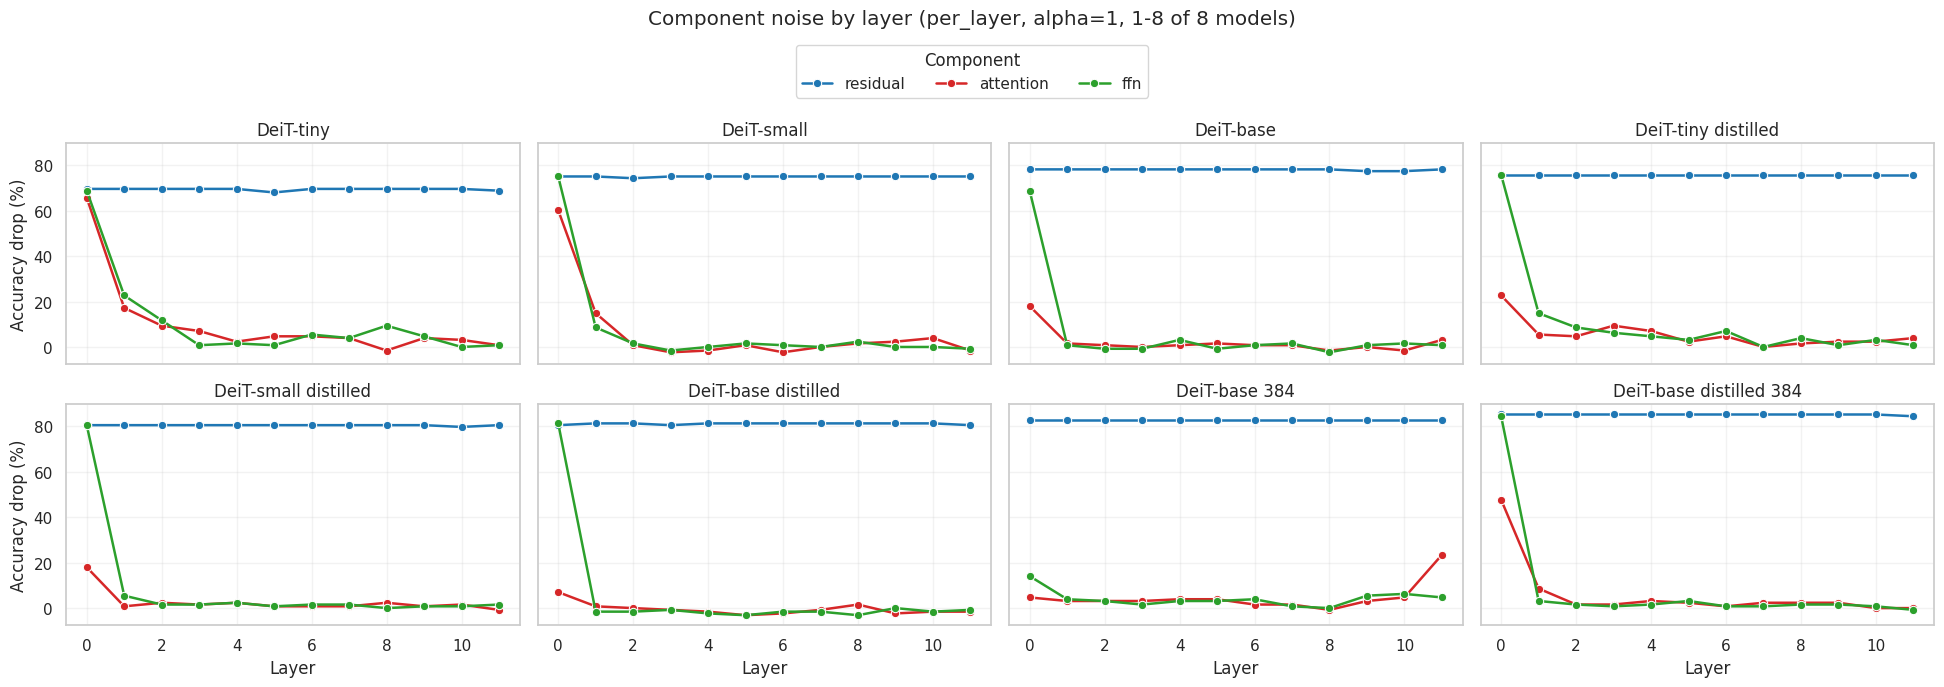

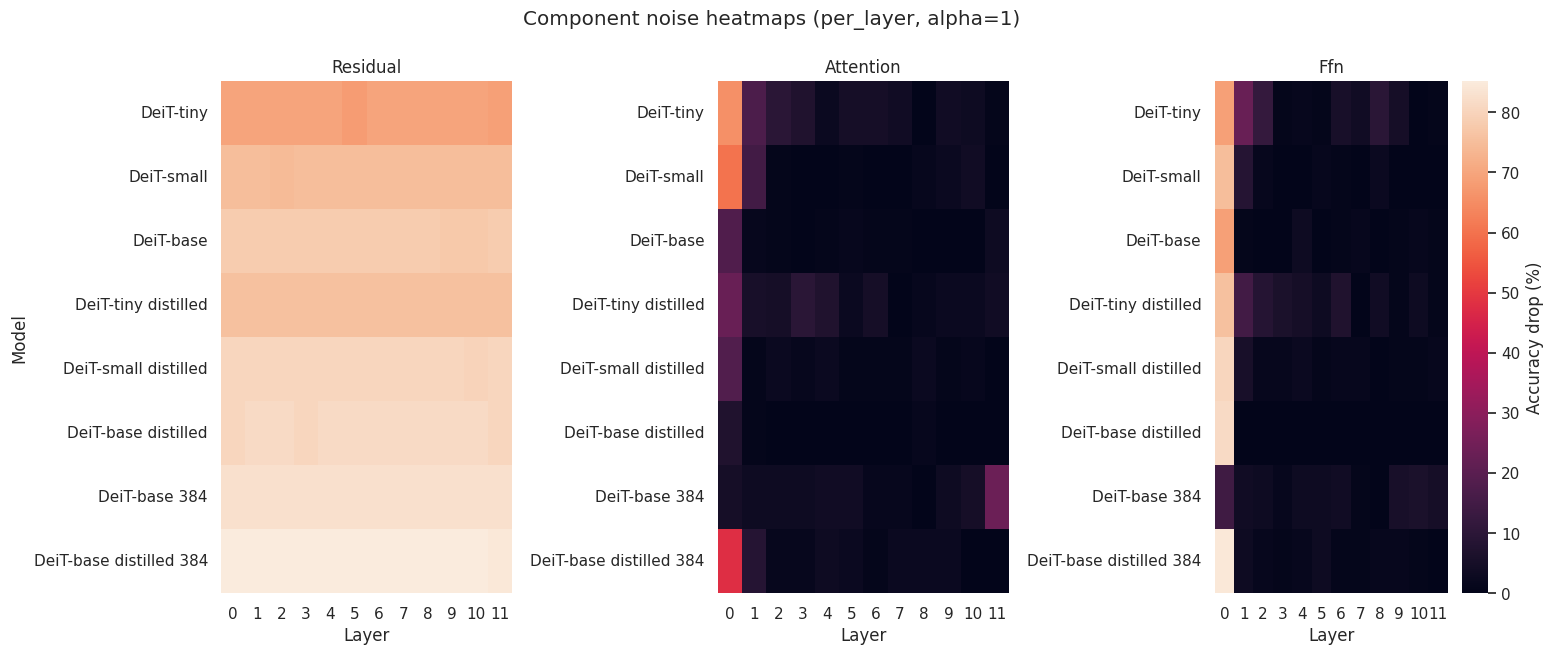

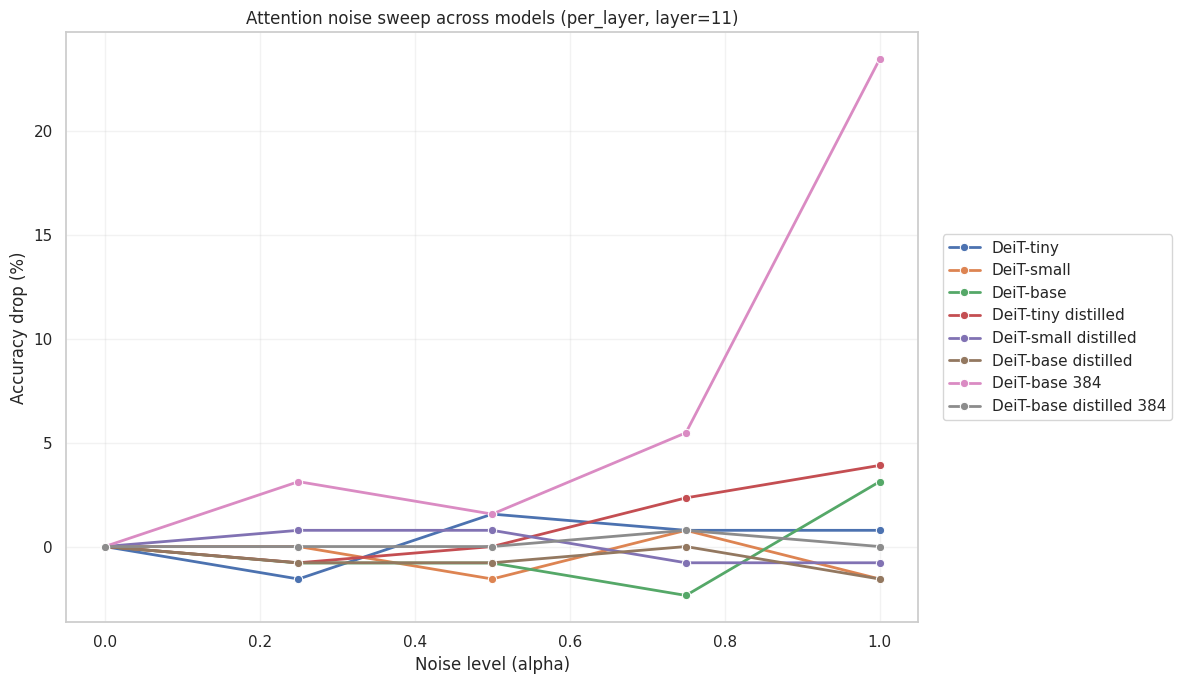

In [15]:
plot_component_noise_report(component_noise_results, selected_specs, mode="per_layer", alpha=1.0)
plot_component_noise_heatmaps(component_noise_results, selected_specs, mode="per_layer", alpha=1.0)
plot_component_alpha_sweep(component_noise_results, selected_specs, mode="per_layer", component="attention")

In [16]:
cached_results_path = Path(EXPERIMENT_CONFIG["results_dir"]) / "component_noise_results.csv"
component_noise_results = pd.read_csv(cached_results_path)
component_noise_results.head()

,model_name,repo_id,component,mode,layer,alpha,accuracy,baseline_accuracy,accuracy_drop,num_noisy_layers,samples_evaluated
0,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.00,69.53,69.53,0.00,1,128
1,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.25,16.41,69.53,53.12,1,128
2,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.50,0.00,69.53,69.53,1,128
3,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,0.75,0.00,69.53,69.53,1,128
4,DeiT-tiny,facebook/deit-tiny-patch16-224,residual,per_layer,0,1.00,0.00,69.53,69.53,1,128
